# Análisis Espacial y Detección de Objetos

Este notebook utiliza YOLO (Estándar de la industria) para detectar objetos y categorizarlos en 3 imágenes dadas.

In [1]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import cv2

Utilizaremos YOLOv8 Nano por su velocidad

In [2]:
# Cargar el modelo oficial de Ultralytics
model = YOLO('yolov8n.pt')

print("Modelo cargado y listo para detectar (80 objetos en su entrenamiento)")

Modelo cargado y listo para detectar (80 objetos en su entrenamiento)


In [3]:
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

Función para detectar y contar

In [4]:
def detect_and_count(model, image):
    """Run YOLO detection, plot results and return a summary count."""
    results = model(image)

    res_plotted = results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(res_rgb)
    plt.axis('off')
    plt.show()

    conteo = results[0].boxes.cls.tolist()
    nombres = results[0].names
    summary = []
    for idx in sorted(set(conteo)):
        cantidad = conteo.count(idx)
        summary.append((nombres[idx], cantidad))

    return results, summary


## Pruebas y Resultados


image 1/1 C:\Users\User\Desktop\Example\Data\shibuya.jpg: 480x640 3 persons, 7 cars, 1 backpack, 1 handbag, 675.8ms
Speed: 14.4ms preprocess, 675.8ms inference, 9.3ms postprocess per image at shape (1, 3, 480, 640)


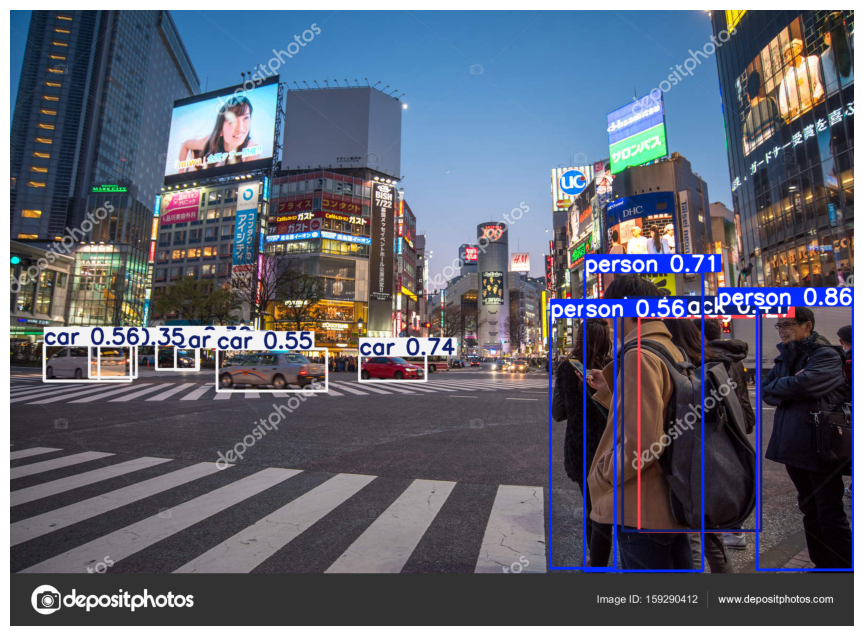

([ultralytics.engine.results.Results object with attributes:
  
  boxes: ultralytics.engine.results.Boxes object
  keypoints: None
  masks: None
  names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'po

In [5]:
# Cruce de Shibuya
detect_and_count(model, 'C:/Users/User/Desktop/Example/Data/shibuya.jpg')

Tenemos alta precisión, porque detectamos de forma correcta todos los objetos detectados.

Tenemos bajo recall, porque no detectamos TODOS los objetos a detectar.

Tenemos bajo UoL, porque en los cuadros blancos de los carros, hay más de un objeto por cuadro.


image 1/1 C:\Users\User\Desktop\Example\Data\times_square.jpg: 448x640 6 cars, 1 potted plant, 1 clock, 440.3ms
Speed: 4.5ms preprocess, 440.3ms inference, 3.7ms postprocess per image at shape (1, 3, 448, 640)


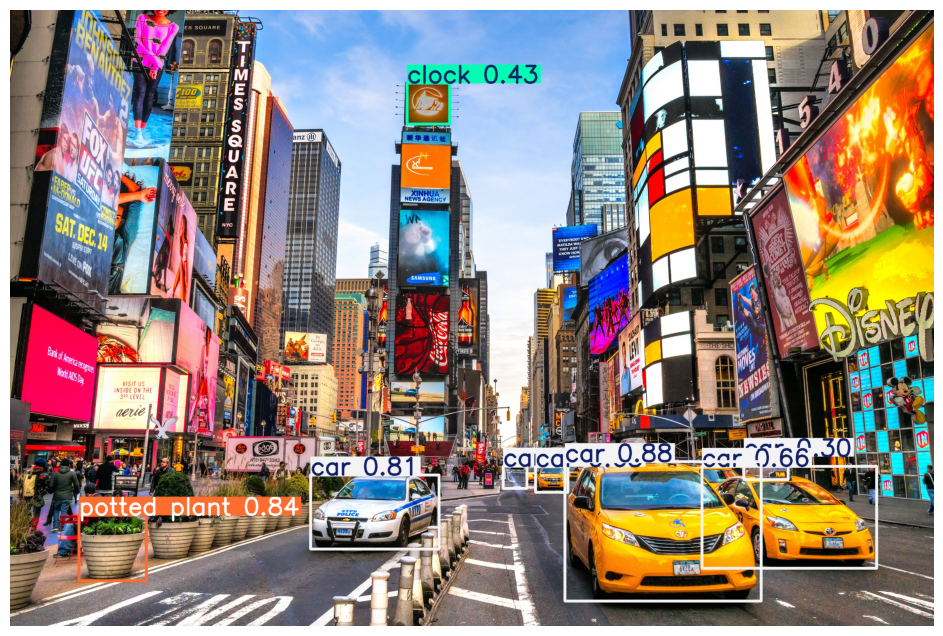

([ultralytics.engine.results.Results object with attributes:
  
  boxes: ultralytics.engine.results.Boxes object
  keypoints: None
  masks: None
  names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'po

In [7]:
# Times Square
detect_and_count(model,'C:/Users/User/Desktop/Example/Data/times_square.jpg')

Tenemos alta precisión, porque detectamos de forma correcta todos los objetos detectados.

Tenemos alto recall, porque no detectamos TODOS los objetos a detectar, pero detectó la gran mayoría.

Tenemos alto UoL, porque solamente vemos un objeto por cuadro.


image 1/1 C:\Users\User\Desktop\Example\Data\gran_via.jpg: 544x640 11 persons, 1 car, 545.2ms
Speed: 7.8ms preprocess, 545.2ms inference, 7.3ms postprocess per image at shape (1, 3, 544, 640)


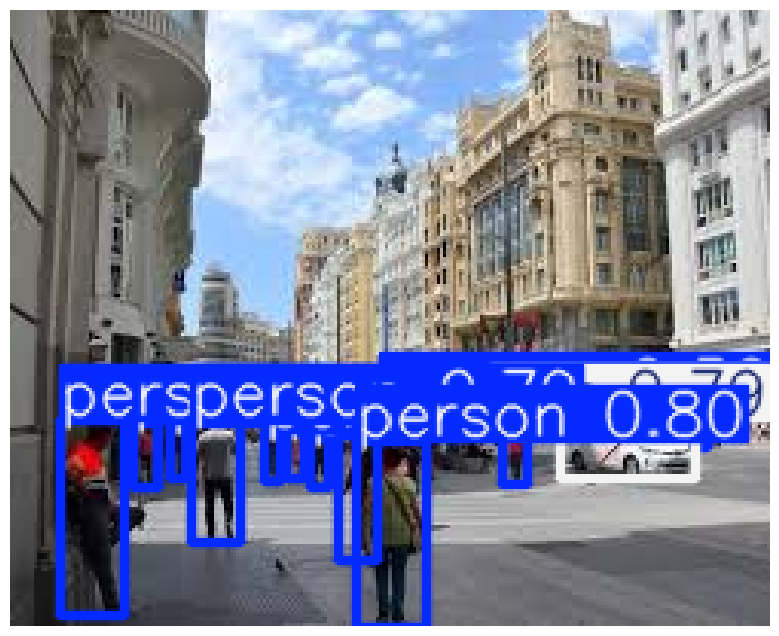

([ultralytics.engine.results.Results object with attributes:
  
  boxes: ultralytics.engine.results.Boxes object
  keypoints: None
  masks: None
  names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'po

In [8]:
# Gran Vía
detect_and_count(model,'C:/Users/User/Desktop/Example/Data/gran_via.jpg')

Tenemos alta precisión, porque detectamos de forma correcta todos los objetos detectados.

Tenemos medio recall, porque no detectamos TODOS los objetos a detectar y se quedó por debajo de la mediana.

Tenemos medio UoL, porque en las bicicletas falló al colocar un objeto por recuadro.